# Linear regression

## Importación de librerías y paquetes y definición de constantes

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# from tqdm import tqdm
import warnings


In [3]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Recopilación de datos

In [4]:
df = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/medical_insurance_cost.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Análisis descriptivo 

In [6]:
df.shape

(1338, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [9]:
df.duplicated().sum()

np.int64(1)

### Hay 1 fila duplicada, asi que nos aseguramos de no dejar duplicados en todo el dataset

In [10]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(1337, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
df.duplicated().sum()

np.int64(0)

### Valores nulos o faltantes:

In [12]:
df.isnull().sum().sort_values(ascending=False) / len(df)

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

#### No hay valores nulos

### Limpieza de datos: Eliminar información irrelevante
    
A priori no vamos a eliminar ninguna variable dado el tamaño del dataset y lo "amigable" que parece

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


## Análisis de variables:

### Variables univariante: variables categóricas

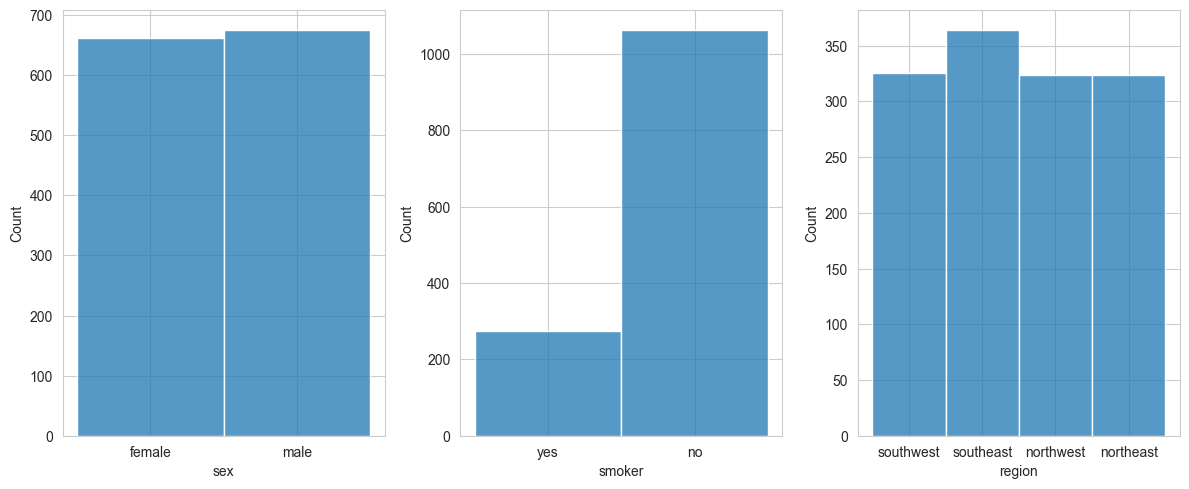

In [16]:
fig, axis = plt.subplots(1, 3, figsize=(12, 5))
sns.set_style("whitegrid")
sns.histplot(ax=axis[0], data=df, x="sex")
sns.histplot(ax=axis[1], data=df, x="smoker")
sns.histplot(ax=axis[2], data=df, x="region")
plt.tight_layout()
plt.show()

### Variables univariante: variables númericas

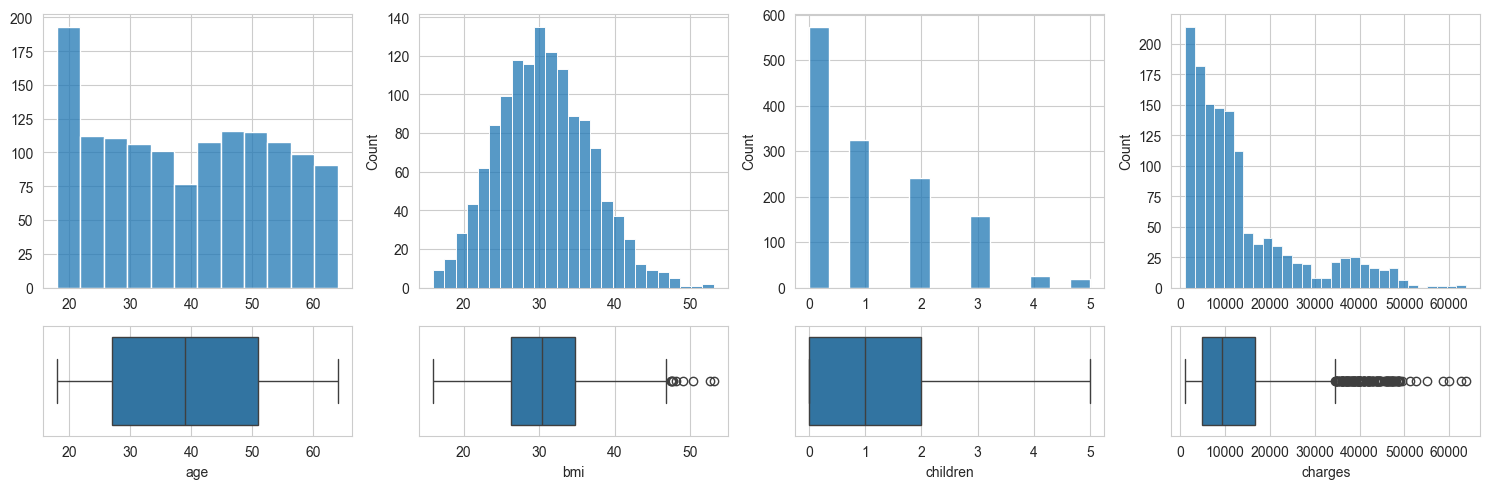

In [19]:
fig, axis = plt.subplots(2, 4, figsize=(15, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="age").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="age")
sns.histplot(ax=axis[0, 1], data=df, x="bmi").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="bmi")
sns.histplot(ax=axis[0, 2], data=df, x="children").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="children")
sns.histplot(ax=axis[0, 3], data=df, x="charges").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="charges")


plt.tight_layout()
plt.show()

> #### Observaciones:
>
> - La combinación de los dos gráficos nos permite conocer las distribuciones y sus características estadísticas.
> - De la visualización resultante podemos tener claro las variables que cuentan con valores atípicos. En este caso la variable charges puede ser relevante para el estudio de valores atípicos

### Análisis de Variables Multivariante: procedemos a buscar todas las posibles relaciones que existen entre las variables

### Codificación de variables categóricas para el estudio de correlaciones, análisis númerico-categórico

In [20]:
df["sex_n"] = pd.factorize(df["sex"])[0]
df["smoker_n"] = pd.factorize(df["smoker"])[0]
df["region_n"] = pd.factorize(df["region"])[0]

In [21]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'sex_n',
       'smoker_n', 'region_n'],
      dtype='object')

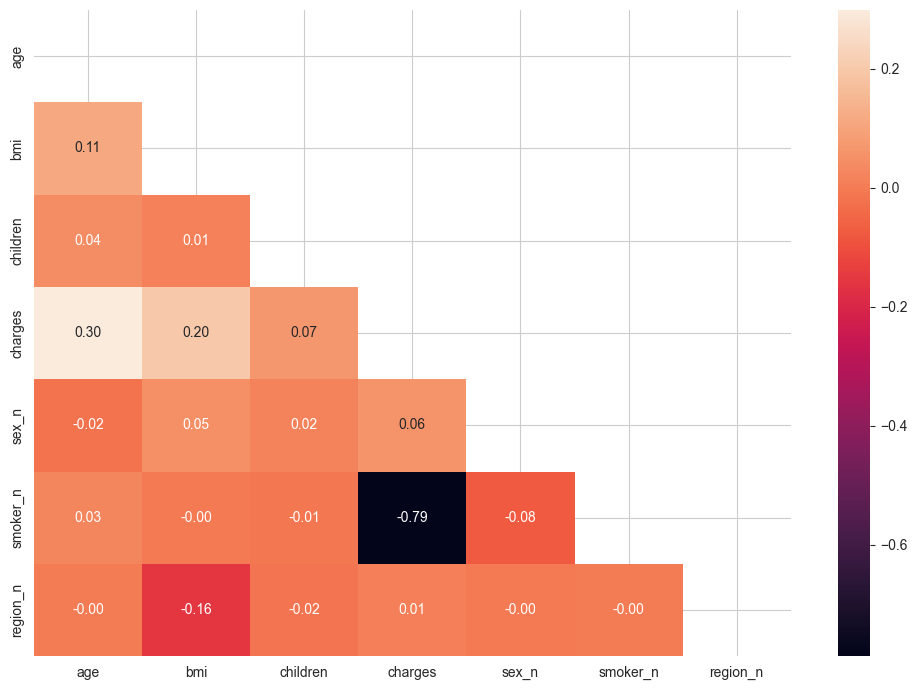

In [23]:
corr = df[['age', 'bmi', 'children', 'charges', 'sex_n', 'smoker_n', 'region_n']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

### Observaciones:
>- Distintas correlaciones a tener en cuenta: age-charges, bmi-region/charges, charges-smoker.

Procedemos a estudiar de forma detallada las correlaciones para sacar una conclusión 

### Análisis de variables multivariante: númerico-númerico

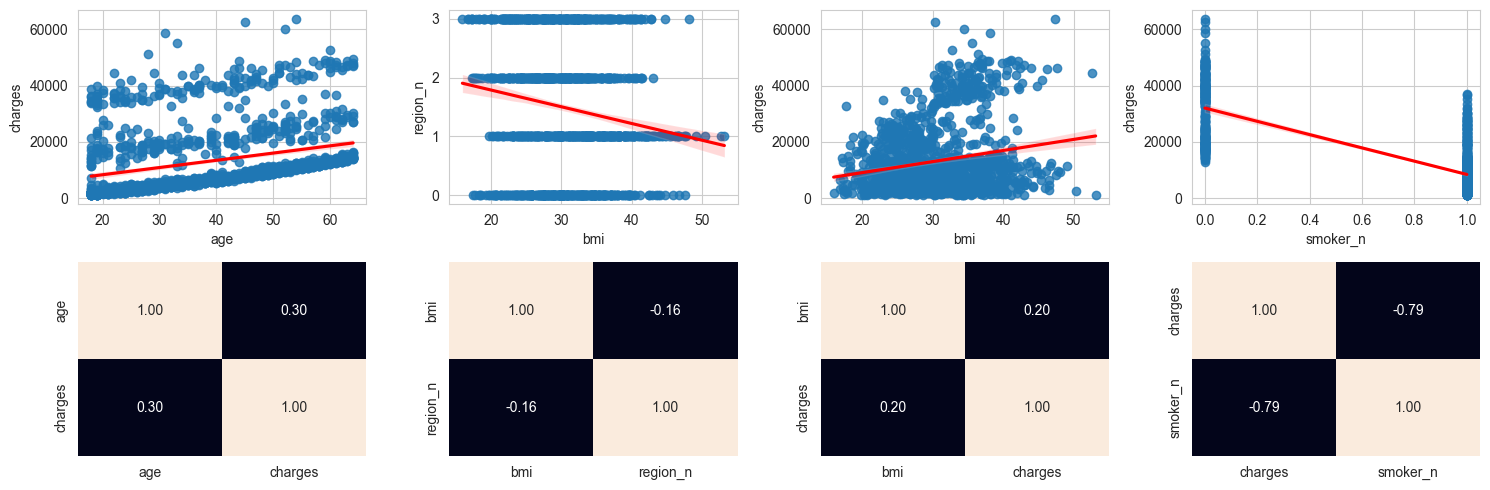

In [30]:
corr_age_charges = df[["age", "charges"]].corr()
corr_bmi_region = df[["bmi", "region_n"]].corr()
corr_bmi_charges = df[["bmi", "charges"]].corr()
corr_charges_smoker = df[["charges", "smoker_n"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="age", y="charges", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_age_charges, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="bmi", y="region_n", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_bmi_region, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="bmi", y="charges", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_bmi_charges, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="smoker_n", y="charges", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_charges_smoker, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

### Observaciones:

1. La prima aumenta con la edad
2. El bmi depende de la región
3. La prima aumenta con el bmi
4. La prima aumenta si el cliente es fumador

### Análisis de variables multivariante: categórico-categórico

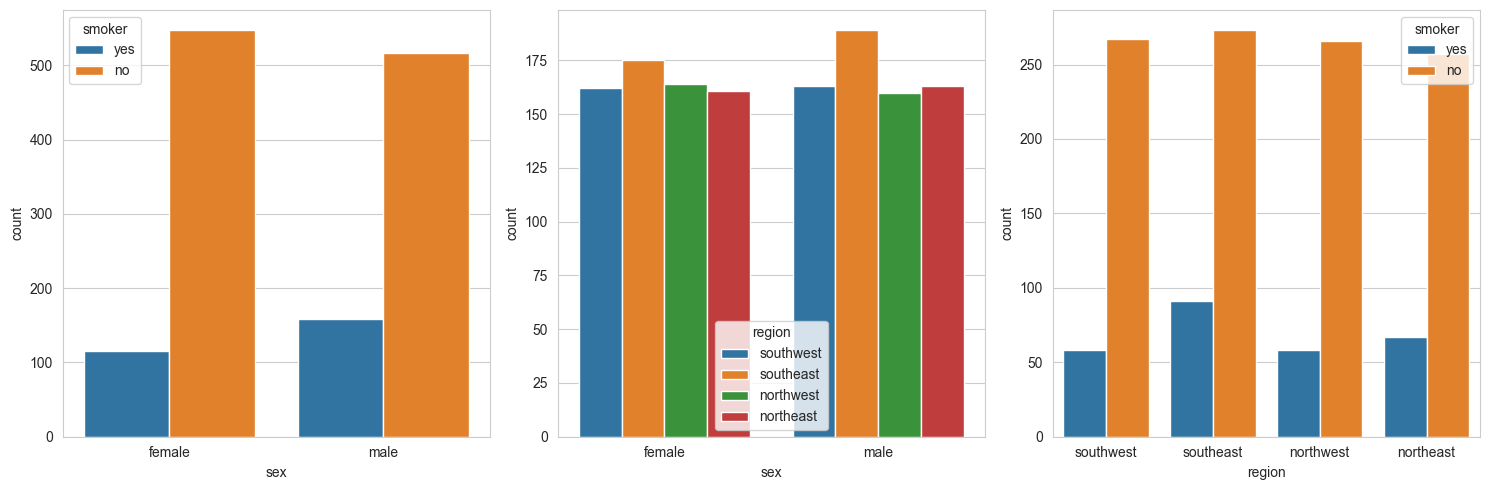

In [31]:
fig, axis = plt.subplots(1, 3, figsize=(15, 5))

sns.set_style("whitegrid")
sns.countplot(ax=axis[0], data=df, x="sex", hue="smoker")
sns.countplot(ax=axis[1], data=df, x="sex", hue="region")
sns.countplot(ax=axis[2], data=df, x="region", hue="smoker")

plt.tight_layout()
plt.show()

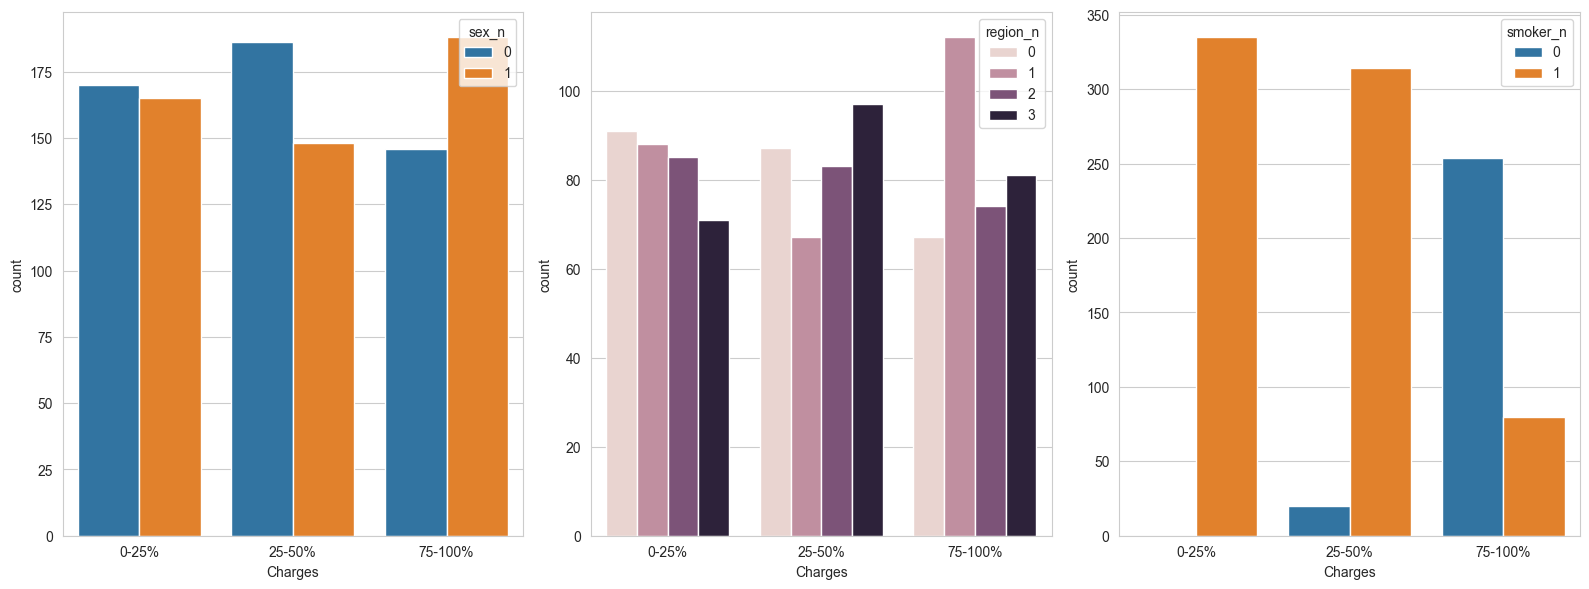

In [36]:
fig, axis = plt.subplots(1, 3, figsize=(16, 6))
bins = [df["charges"].quantile(0.25), df["charges"].quantile(0.50), df["charges"].quantile(0.75), df["charges"].max()]
labels = ["0-25%", "25-50%", "75-100%"]
df["charges_range"] = pd.cut(df["charges"], bins=bins, labels=labels, include_lowest=True)
sns.set_style("whitegrid")
sns.countplot(ax=axis[0], data=df, x="charges_range", hue="sex_n").set_xlabel('Charges')
sns.countplot(ax=axis[1], data=df, x="charges_range", hue="region_n").set_xlabel('Charges')
sns.countplot(ax=axis[2], data=df, x="charges_range", hue="smoker_n").set_xlabel('Charges')
plt.tight_layout()
plt.show()

### Observaciones: 
>- Parece que el contacto con los clientes en la campaña anterior influye en la contratación del producto
>- Hay un porcentaje de clientes con préstamo hipotecario que tienen también un prestamo personal, alrededor de un 25%
>- Tener una deuda por impago no parece determinante ya que los datos se distribuyen entre no y unknown

## Ingeniería de características

### Análisis de outliers

#### Análisis descriptivo

In [162]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.0,32.0,38.0,47.0,98.0
campaign,41176.0,2.567879,2.770318,1.0,1.0,2.0,3.0,56.0
previous,41176.0,0.173013,0.494964,0.0,0.0,0.0,0.0,7.0
job_n,41176.0,3.673863,2.454340,0.0,2.0,3.0,4.0,11.0
default_n,41176.0,0.208908,0.406713,0.0,0.0,0.0,0.0,2.0
housing_n,41176.0,0.571959,0.541216,0.0,0.0,1.0,1.0,2.0
loan_n,41176.0,0.199825,0.456055,0.0,0.0,0.0,0.0,2.0
y_n,41176.0,0.112663,0.316184,0.0,0.0,0.0,0.0,1.0


#### Visualización

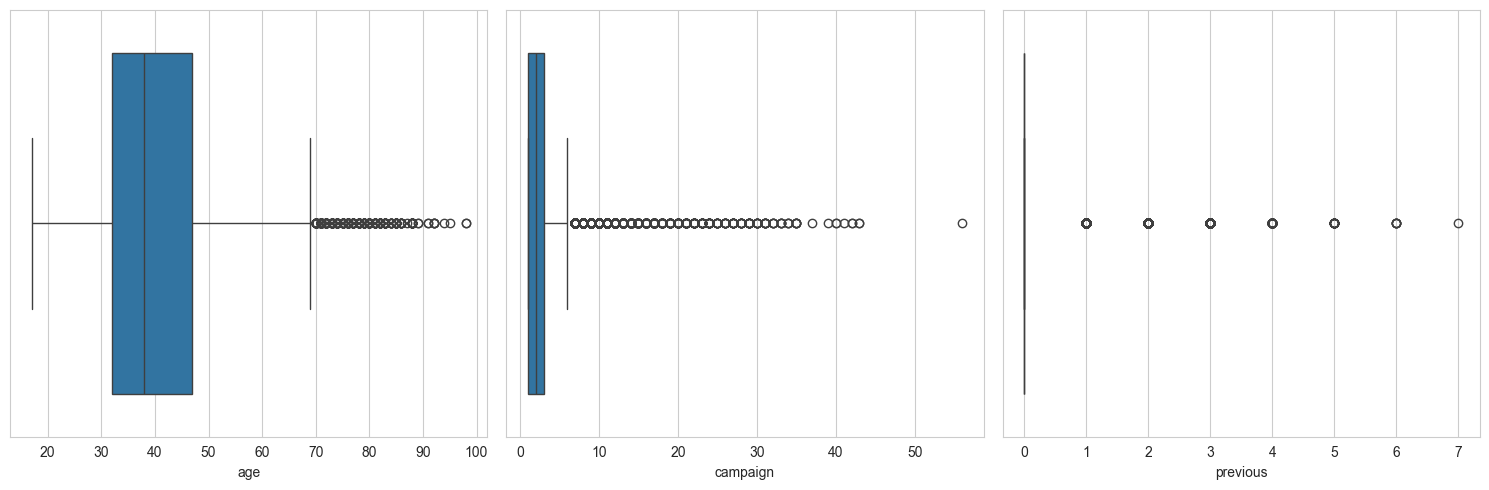

In [163]:
fig, axis = plt.subplots(1, 3, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, x="age")
sns.boxplot(ax=axis[1], data=df, x="campaign")
sns.boxplot(ax=axis[2], data=df, x="previous")
plt.tight_layout()
plt.show()

#### Valores atípicos 'age'

In [164]:
df['age'].describe()

count    41176.00000
mean        40.02380
std         10.42068
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [165]:

q1_age = df["age"].quantile(0.25)
q3_age = df["age"].quantile(0.75)
iqr_age = q3_age - q1_age

# Definir los límites inferior y superior
lower_limit_age = 0 if (q1_age - 1.5 * iqr_age) < 0 else q1_age - 1.5 * iqr_age
upper_limit_age = q3_age + 1.5 * iqr_age

f"Límite superior: {round(upper_limit_age, 2)}, Límite inferior: {round(lower_limit_age, 2)}, Rango intercuartílico: {round(iqr_age, 2)}"

'Límite superior: 69.5, Límite inferior: 9.5, Rango intercuartílico: 15.0'

In [166]:
df[df['age'] > 70]

,age,job,default,housing,loan,campaign,previous,y,job_n,default_n,housing_n,loan_n,y_n
27757,76,retired,no,no,yes,9,0,no,5,0,0,1,0
27780,73,retired,no,yes,no,1,1,no,5,0,1,0,0
27800,88,retired,no,yes,no,1,0,no,5,0,1,0,0
27802,88,retired,no,no,no,2,0,yes,5,0,0,0,1
27805,88,retired,no,yes,yes,5,0,yes,5,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40986,84,retired,unknown,yes,yes,4,1,no,5,1,1,1,0
40996,81,retired,no,yes,no,1,2,yes,5,0,1,0,1
41004,80,retired,no,yes,no,1,1,yes,5,0,1,0,1
41183,73,retired,no,yes,no,1,0,yes,5,0,1,0,1


#### Considero que son valores atípicos normales en la distribución y decido mantenerlos

#### Valores atípicos 'campaign'

In [167]:
df['campaign'].describe()

count    41176.000000
mean         2.567879
std          2.770318
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [168]:
q1_campaign = df['campaign'].quantile(0.25)
q3_campaign = df['campaign'].quantile(0.75)
iqr_campaign = q3_campaign - q1_campaign

# Definir los límites inferior y superior
lower_limit_campaign = 0 if (q1_campaign - 1.5 * iqr_campaign) < 0 else q1_campaign - 1.5 * iqr_campaign
upper_limit_campaign = q3_campaign + 1.5 * iqr_campaign

f"Límite superior: {round(upper_limit_campaign, 2)}, Límite inferior: {round(lower_limit_campaign, 2)}, Rango intercuartílico: {round(iqr_campaign, 2)}"

'Límite superior: 6.0, Límite inferior: 0, Rango intercuartílico: 2.0'

In [169]:
df[df['campaign']>6]

,age,job,default,housing,loan,campaign,previous,y,job_n,default_n,housing_n,loan_n,y_n
887,54,admin.,no,no,no,7,0,no,2,0,0,0,0
1043,41,technician,unknown,no,no,8,0,no,4,1,0,0,0
1094,40,technician,no,yes,no,8,0,no,4,0,1,0,0
1097,51,blue-collar,unknown,yes,no,7,0,no,3,1,1,0,0
1230,48,blue-collar,no,no,no,7,0,no,3,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40611,75,retired,no,no,no,9,1,no,5,0,0,0,0
40631,88,retired,no,yes,no,7,0,no,5,0,1,0,0
40698,29,technician,no,yes,no,7,5,no,4,0,1,0,0
40821,33,technician,no,yes,no,9,2,no,4,0,1,0,0


#### Considero que son valores normales y mantengo los outliers.

#### Valores atípicos 'previous'

In [170]:
df['previous'].describe().T

count    41176.000000
mean         0.173013
std          0.494964
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [171]:
q1_previous = df['previous'].quantile(0.25)
q3_previous = df['previous'].quantile(0.75)
iqr_previous = q3_previous - q1_previous

# Definir los límites inferior y superior
lower_limit_previous = 0 if (q1_previous - 1.5 * iqr_previous) < 0 else q1_previous - 1.5 * iqr_previous
upper_limit_previous = q3_previous + 1.5 * iqr_previous

f"Límite superior: {round(upper_limit_previous, 2)}, Límite inferior: {round(lower_limit_previous, 2)}, Rango intercuartílico: {round(iqr_previous, 2)}"

'Límite superior: 0.0, Límite inferior: 0.0, Rango intercuartílico: 0.0'

#### Hay una incongruencia matemática y cualquier valor se puede considerar atípico, sin embargo considero mantener la variable porque me parece interesante la influencia de campañas anteriores sobre la actual

### Análisis de valores faltantes

In [172]:
df.isnull().sum().sort_values(ascending=False) / len(df)

age          0.0
job          0.0
default      0.0
housing      0.0
loan         0.0
campaign     0.0
previous     0.0
y            0.0
job_n        0.0
default_n    0.0
housing_n    0.0
loan_n       0.0
y_n          0.0
dtype: float64

#### En este caso no existen valores nulos debido a la limpieza de datos que hemos hecho previamente, así como tampoco es necesario hacer inferencia de características porque no tienen ninguna relación

## Split de datos

### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable 'y' como target y la codificamos en valores binarios

In [173]:
label_encoder = LabelEncoder()
# 2. Entrenamos los encoders con los datos de entrenamiento (ajustamos) fit
y_cod = label_encoder.fit_transform(df['y'])
y_cod

array([0, 0, 0, ..., 0, 1, 0], shape=(41176,))

In [174]:
X = df.drop(["y","y_n"], axis=1)
y = y_cod

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

X_train

,age,job,default,housing,loan,campaign,previous,job_n,default_n,housing_n,loan_n
6707,35,blue-collar,no,yes,yes,3,0,3,0,1,1
38289,37,technician,no,yes,no,1,1,4,0,1,0
25861,34,admin.,no,yes,no,1,0,2,0,1,0
20623,33,admin.,no,no,no,1,0,2,0,0,0
27944,32,admin.,no,unknown,unknown,3,0,2,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...
5295,41,self-employed,no,yes,no,6,0,8,0,1,0
1727,33,technician,no,no,no,1,0,4,0,0,0
35663,37,admin.,unknown,yes,no,1,0,2,1,1,0
25728,45,admin.,no,yes,no,1,1,2,0,1,0


## Scaling & Encoding

### Scaling

#### Usamos el método  standarscaler porque los datos están sesgados y hay valores atípicos

#### Scaling X_train

In [175]:
standard_scaler = StandardScaler()  # Instancia de: from sklearn.preprocessing import MinMaxScaler

num_variables = ['age', 'campaign', 'previous']
standard_train_features = standard_scaler.fit_transform(X_train[num_variables])

X_train_standard = pd.DataFrame(standard_train_features,
                               index=X_train.index,
                               columns=num_variables)
X_train_standard

,age,campaign,previous
6707,-0.485589,0.156841,-0.349864
38289,-0.294120,-0.567294,1.672691
25861,-0.581323,-0.567294,-0.349864
20623,-0.677057,-0.567294,-0.349864
27944,-0.772791,0.156841,-0.349864
...,...,...,...
5295,0.088817,1.243044,-0.349864
1727,-0.677057,-0.567294,-0.349864
35663,-0.294120,-0.567294,-0.349864
25728,0.471754,-0.567294,1.672691


#### Scaling X_test

In [176]:
standard_test_features = standard_scaler.transform(X_test[num_variables])

X_test_standard = pd.DataFrame(standard_test_features,
                               index=X_test.index,
                               columns=num_variables)
X_test_standard

,age,campaign,previous
6686,0.280286,-0.205227,-0.349864
28748,-1.347197,0.518909,-0.349864
18255,-0.485589,-0.205227,-0.349864
32003,-0.102651,1.967180,-0.349864
32752,-1.155729,-0.205227,-0.349864
...,...,...,...
28448,-1.538666,-0.567294,1.672691
38865,-1.442932,0.518909,-0.349864
25516,-0.964260,-0.567294,-0.349864
28454,0.471754,0.156841,1.672691


### Encoding

#### Usamos el método one-hot encoding ya que las variables a codificar no tienen un orden determinado

#### Encoding X_train

In [177]:
# Genero una lista con los nombres de las columnas categóricas
cat_variables = ['job', 'default', 'housing', 'loan']

# Creamos la instancia del encoder
one_hot_encoder = OneHotEncoder(sparse_output=False)

# Entrenamos y aplicamos el encoder en el conjunto de entrenamiento: X_train
X_train_cat_ohe = one_hot_encoder.fit_transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe,
                               index=X_train.index,
                               columns=one_hot_encoder.get_feature_names_out(cat_variables))

X_train_cat_ohe.head()

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,job_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes
6707,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
38289,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
25861,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
20623,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
27944,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


#### Encoding X_test

In [178]:
# Entrenamos y aplicamos el encoder en el conjunto de test: X_test
X_test_cat_ohe = one_hot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe,
                              index=X_test.index,
                              columns=one_hot_encoder.get_feature_names_out(cat_variables))
X_test_cat_ohe.head()

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,job_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes
6686,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
28748,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
18255,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
32003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
32752,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### Guardado de scalers y encoders

In [179]:
with open('C:/Users/Simón/sayons-intro-ml-new/data/raw/bank-marketing-campaign-data.pkl', 'wb') as file:
    pickle.dump(standard_scaler, file)

In [180]:
with open('C:/Users/Simón/sayons-intro-ml-new/data/raw/bank-marketing-campaign-data.pkl', 'wb') as file2:
    pickle.dump(one_hot_encoder, file2)

## Módelo de regresión logística

### Inicialización y entrenamiento del modelo

In [181]:
X_train = pd.concat([X_train_standard, X_train_cat_ohe], axis=1)
X_test = pd.concat([X_test_standard, X_test_cat_ohe], axis=1)

#### Genera el modelo: genera una instancia de la clase LogisticRegression / Creando el modelo (vacío)

In [182]:
model = LogisticRegression(random_state=24)
# Entrena
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,24
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Predicción del modelo

Una vez se ha entrenado el modelo, se puede utilizar para predecir con el conjunto de datos de prueba.

In [183]:
X_test.shape

(8236, 24)

In [184]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(8236,))

In [185]:
model_accuracy = accuracy_score(y_test, y_pred)
model_accuracy

0.8903593977659058

#### Matriz de confusión

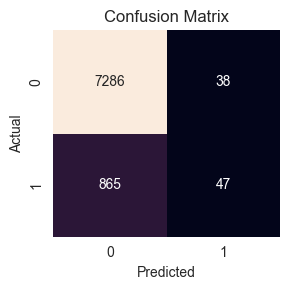

In [186]:
bank_campaign_cm = confusion_matrix(y_test, y_pred)

# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(bank_campaign_cm)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

### Optimización de resultados

In [187]:
hyperparams = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
               'penalty': ['l1', 'l2', 'elasticnet', None],
               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Inicializamos la cuadrícula
grid = GridSearchCV(model,
                    hyperparams,
                    scoring="accuracy",
                    cv=5)
grid

,estimator,LogisticRegre...ndom_state=24)
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [188]:
grid.fit(X_train, y_train)

#grid.best_params_

,estimator,LogisticRegre...ndom_state=24)
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [ ]:
"""best_model_grid = LogisticRegression(penalty='l1',
                                      C=0.1,
                                      solver='liblinear')
best_model_grid.fit(X_train, y_train)

y_pred_grid = best_model_grid.predict(X_train)

grid_accuracy = accuracy_score(y_train, y_pred_grid)

model_accuracy, grid_accuracy"""

#### Utilizando best_params

In [189]:
grid.best_estimator_

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,24
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [190]:
best_model_estimator = grid.best_estimator_

y_pred_grid = best_model_estimator.predict(X_train)

best_estimator_accuracy = accuracy_score(y_train, y_pred_grid)

model_accuracy, best_estimator_accuracy

(0.8903593977659058, 0.888554948391014)

#### El ajuste de hiperparámetros con gridsearch no mejora el resultado 

#### Random search

In [ ]:
# Definimos los parámetros que queremos ajustar
hyperparams = {'C': np.logspace(-4, 4, 20),
               'penalty': ['l1', 'l2', 'elasticnet', None],
               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Inicializamos la búsqueda aleatoria
random_search = RandomizedSearchCV(model,
                                   hyperparams,
                                   n_iter=100,
                                   scoring="accuracy",
                                   cv=5,
                                   random_state=24)
random_search

In [ ]:
random_search.fit(X_train, y_train)

f"Mejores hiperparámetros: {random_search.best_params_}"